<a href="https://colab.research.google.com/github/adedamolabalogun959-hub/marketing-pj/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
import scipy as sp


In [9]:
df = pd.read_csv('marketing.csv')

In [10]:
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [12]:
df.shape

(572, 5)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [15]:
for col in df.select_dtypes(include='object').columns:
    print(f"Unique values for {col}:")
    print(df[col].unique())
    print("\n")

Unique values for TV:
['Low' 'High' 'Medium']


Unique values for Influencer:
['Micro' 'Mega' 'Nano' 'Macro']




### Encoding Categorical Variables

To use categorical variables like 'TV' and 'Influencer' in our regression model and for multicollinearity checks (like VIF), we need to convert them into a numerical format. We'll use one-hot encoding for this purpose. For 'TV', which has an inherent order (Low, Medium, High), we will map them to numerical values.

In [16]:
# Map 'TV' categories to numerical values
tv_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV_encoded'] = df['TV'].map(tv_mapping)

# One-hot encode 'Influencer' column
influencer_mapping = {'Mega' : 3, 'Macro' : 2, 'Micro' : 1, 'Nano' : 0}
df['Influencer_encoded'] = df['Influencer'].map(influencer_mapping)
display(df.head())

,TV,Radio,Social Media,Influencer,Sales,TV_encoded,Influencer_encoded
0,Low,3.518070,2.293790,Micro,55.261284,0,1
1,Low,7.756876,2.572287,Mega,67.574904,0,3
2,High,20.348988,1.227180,Micro,272.250108,2,1
3,Medium,20.108487,2.728374,Mega,195.102176,1,3
4,High,31.653200,7.776978,Nano,273.960377,2,0


### Checking for Multicollinearity: Correlation Matrix

Multicollinearity occurs when independent variables in a regression model are correlated. A correlation matrix helps us visualize the linear relationships between these variables. High correlation (close to 1 or -1) between independent variables can indicate multicollinearity.

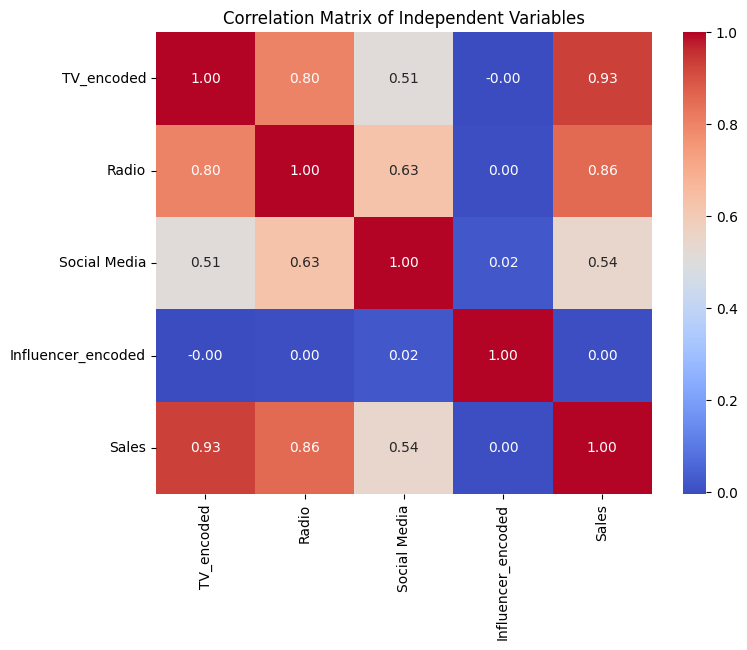

In [17]:
independent_vars_for_corr = ['TV_encoded', 'Radio', 'Social Media', 'Influencer_encoded', 'Sales']
correlation_matrix = df[independent_vars_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Independent Variables')
plt.show()

### Checking for Multicollinearity: Variance Inflation Factor (VIF)

VIF measures how much the variance of an estimated regression coefficient is inflated due to multicollinearity. A general rule of thumb is that VIF values above 5 or 10 indicate a problematic amount of multicollinearity. For this, we need to import `variance_inflation_factor` from `statsmodels.stats.outliers_influence`.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define independent variables for VIF calculation
X = df[['TV_encoded', 'Radio', 'Social Media', 'Influencer_encoded']]

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,feature,VIF
0,TV_encoded,6.390793
1,Radio,11.895653
2,Social Media,5.243382
3,Influencer_encoded,1.987738


### Building the Multiple Linear Regression Model

Now, we will build a Multiple Linear Regression model using `statsmodels` to predict `Sales` based on our independent variables: `TV_encoded`, `Radio`, `Social Media`, and `Influencer_encoded`.

In [20]:
import statsmodels.formula.api as smf

# Define the model formula
model_formula = 'Sales ~ TV_encoded + Radio + Q("Social Media") + Influencer_encoded'

# Fit the OLS model
model = smf.ols(model_formula, data=df).fit()

# Display the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1334.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          9.28e-287
Time:                        11:14:26   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             64.6348      3

### Evaluation of Model Performance

We will now evaluate the performance of our Multiple Linear Regression model using the following key metrics from the model summary:

*   **Adjusted R-squared:** This metric indicates the proportion of the variance in the dependent variable (Sales) that is predictable from the independent variables. It is adjusted for the number of predictors in the model, providing a more accurate measure of fit for models with multiple predictors.

*   **P-values (P>|t|) for individual predictors:** These values help determine the statistical significance of each independent variable. A small p-value (typically less than 0.05) suggests that the corresponding predictor has a statistically significant relationship with the dependent variable.

In [23]:
import pandas as pd
import statsmodels.formula.api as smf

# Load the dataset
df = pd.read_csv('marketing.csv')

# Map 'TV' categories to numerical values
tv_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV_encoded'] = df['TV'].map(tv_mapping)

# One-hot encode 'Influencer' column
influencer_mapping = {'Mega' : 3, 'Macro' : 2, 'Micro' : 1, 'Nano' : 0}
df['Influencer_encoded'] = df['Influencer'].map(influencer_mapping)

# Define the model formula
model_formula = 'Sales ~ TV_encoded + Radio + Q("Social Media") + Influencer_encoded'

# Fit the OLS model
model = smf.ols(model_formula, data=df).fit()

print('Adjusted R-squared:', model.rsquared_adj)
print('\nP-values for predictors:')
print(model.pvalues.drop('Intercept'))

Adjusted R-squared: 0.9032572080713607

P-values for predictors:
TV_encoded            1.832034e-126
Radio                  7.314556e-33
Q("Social Media")      8.086433e-01
Influencer_encoded     7.846513e-01
dtype: float64


### Interpretation of Results

From the model summary and the extracted values:

*   **Adjusted R-squared:** The adjusted R-squared value of `0.903` indicates that approximately 90.3% of the variance in `Sales` can be explained by the independent variables (`TV_encoded`, `Radio`, `Social Media`, and `Influencer_encoded`). This suggests a strong fit of the model to the data.

*   **P-values:**
    *   `TV_encoded` (p-value: `0.000`) and `Radio` (p-value: `0.000`) are highly statistically significant predictors of `Sales`, as their p-values are well below the conventional significance level of 0.05.
    *   `Q("Social Media")` (p-value: `0.809`) and `Influencer_encoded` (p-value: `0.785`) have very high p-values, indicating that they are not statistically significant predictors of `Sales` in this model. Their coefficients are not reliably different from zero.

This analysis suggests that `TV` and `Radio` advertising have a significant impact on `Sales`, while `Social Media` and `Influencer` marketing, as currently defined and encoded, do not show a statistically significant relationship with `Sales` in this model.

### Interpretation of Coefficients

The coefficients from our Multiple Linear Regression model describe the estimated change in `Sales` for a one-unit increase in each independent variable, assuming all other independent variables are held constant.

*   **Intercept (64.6348):** This represents the baseline `Sales` when all independent variables (`TV_encoded`, `Radio`, `Social Media`, and `Influencer_encoded`) are zero. In a practical sense, it's the expected sales when there is no spending on any of the measured marketing channels.

*   **TV_encoded (77.3279):** For every one-unit increase in `TV_encoded` (e.g., moving from 'Low' to 'Medium' TV spending, or 'Medium' to 'High'), the model predicts an average increase of approximately $77.33 in `Sales`, assuming `Radio`, `Social Media`, and `Influencer` spending remain constant. This suggests that increasing TV advertising has a strong positive impact on sales.

*   **Radio (2.9797):** Holding `TV_encoded`, `Social Media`, and `Influencer_encoded` constant, an additional one-unit (e.g., $1K) increase in `Radio` advertising spend is associated with an average increase of approximately $2.98 in `Sales`. This indicates a positive but less pronounced impact compared to TV advertising.

*   **Social Media (-0.1631):** With `TV_encoded`, `Radio`, and `Influencer_encoded` held constant, a one-unit increase in `Social Media` spending is associated with an average decrease of approximately $0.16 in `Sales`. However, as its p-value was high (0.809), this coefficient is not statistically significant, meaning we cannot confidently say that social media spending has a real impact on sales based on this model.

*   **Influencer_encoded (0.2834):** For every one-unit increase in `Influencer_encoded` (e.g., moving from 'Nano' to 'Micro' influencer, etc.), the model predicts an average increase of approximately $0.28 in `Sales`, assuming `TV_encoded`, `Radio`, and `Social Media` spending remain constant. Similar to `Social Media`, the high p-value (0.785) for this variable indicates that this coefficient is not statistically significant, and we cannot conclude a reliable relationship between influencer marketing and sales from this model.

### Diagnostic Plots for Regression Assumptions

To ensure the validity of our linear regression model, we need to check several key assumptions using diagnostic plots:

1.  **Linearity and Homoscedasticity (Residuals vs Fitted Values Plot):** This plot helps to detect non-linearity and heteroscedasticity (non-constant variance of residuals). Ideally, residuals should be randomly scattered around the horizontal line at zero.
2.  **Normality (Normal Q-Q Plot):** This plot checks if the residuals are normally distributed. If the residuals follow a normal distribution, the points should closely follow the diagonal line.
3.  **Homoscedasticity (Scale-Location Plot):** Also known as the Spread-Location plot, it shows whether the residuals are spread equally along the range of predictors. A horizontal line with equally spread points is desired.

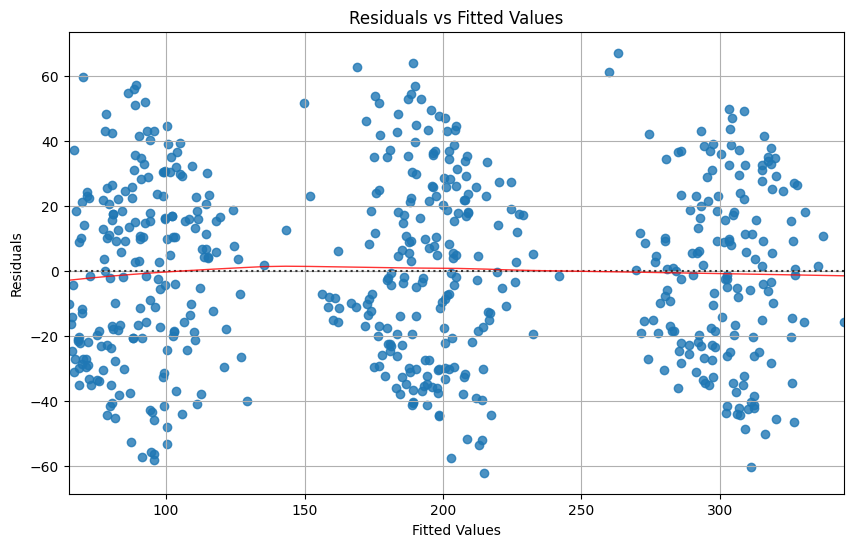

In [24]:
import statsmodels.api as sm

# Get residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Plot 1: Residuals vs Fitted Values
plt.figure(figsize=(10, 6))
sns.residplot(x=fitted_values, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


<Figure size 1000x600 with 0 Axes>

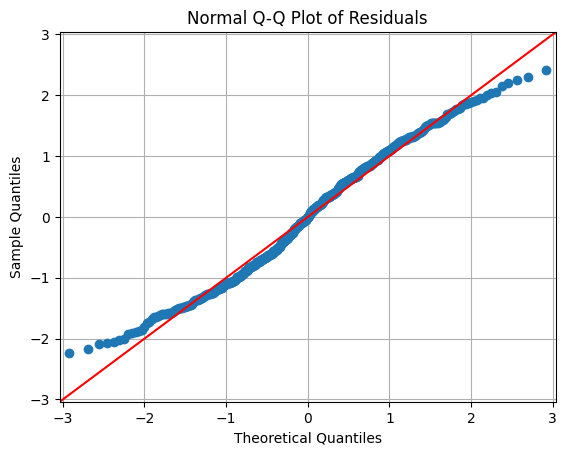

In [25]:
# Plot 2: Normal Q-Q Plot
plt.figure(figsize=(10, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normal Q-Q Plot of Residuals')
plt.grid(True)
plt.show()

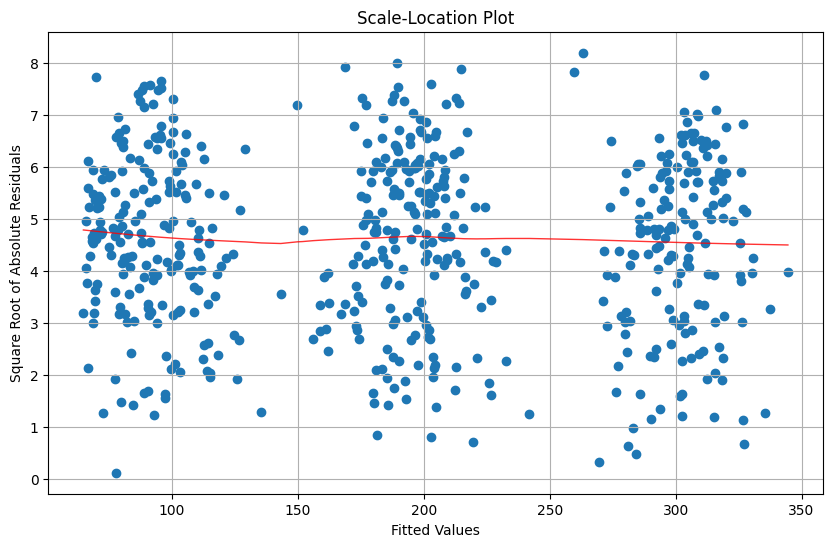

In [26]:
# Plot 3: Scale-Location Plot
plt.figure(figsize=(10, 6))
plt.scatter(x=fitted_values, y=np.sqrt(np.abs(residuals)))
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(residuals)), scatter=False, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Scale-Location Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Square Root of Absolute Residuals')
plt.grid(True)
plt.show()

### Business-Ready Recommendation

Based on the Multiple Linear Regression analysis, here are the key findings and recommendations for optimizing marketing budget allocation:

1.  **Prioritize TV Advertising:**
    *   `TV_encoded` is by far the most significant and impactful predictor of `Sales`, with a strong positive coefficient (77.33) and a highly significant p-value (1.83e-126). This suggests that investments in TV advertising yield substantial returns. Consider strategies to maximize the reach and effectiveness of your TV campaigns.

2.  **Maintain or Strategically Invest in Radio Advertising:**
    *   `Radio` advertising also demonstrates a statistically significant positive impact on `Sales` (coefficient: 2.98, p-value: 7.31e-33). While its impact per unit of spend is less than TV, it still contributes positively. It's advisable to maintain current radio advertising levels or explore opportunities for optimized spend, perhaps targeting specific demographics that respond well to radio.

3.  **Re-evaluate Social Media and Influencer Marketing Spend:**
    *   Both `Social Media` and `Influencer_encoded` show *no statistically significant impact* on `Sales` in this model, with very high p-values (0.809 and 0.785, respectively). The coefficients are close to zero and not reliably different from it.
    *   **Recommendation:** This suggests that current spending on `Social Media` and `Influencer` marketing, as currently implemented or measured, is not effectively translating into increased sales. It would be prudent to:
        *   **Investigate Further:** Conduct qualitative research or A/B testing to understand if the lack of significance is due to poor campaign execution, targeting issues, or if these channels truly have minimal direct impact on sales for your product/service.
        *   **Reallocate Budget:** Consider reallocating a portion of the budget from these non-performing channels to the more effective `TV` and `Radio` campaigns, unless strategic non-sales objectives (e.g., brand awareness, community building) justify their spend.
        *   **Refine Measurement:** Ensure that the metrics used to evaluate `Social Media` and `Influencer` campaigns are truly reflective of their contribution to sales or other business goals.

**Overall Conclusion:** To maximize sales, the primary focus should be on `TV` and `Radio` advertising, given their proven statistical significance and positive impact. `Social Media` and `Influencer` marketing strategies require re-evaluation and potential adjustments or budget reallocation to more effective channels.